In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc, precision_recall_curve

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, classification_report, brier_score_loss, confusion_matrix, log_loss
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight

import shap

/Users/ashademeij/.pyenv/versions/3.9.18/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# same code used for each dataset, just change the path
df = pd.read_csv("dmean_df.csv")
print(df.shape)

# df = pd.read_csv("dmax_df.csv")
# print(df.columns)
# print(df.shape)

(1789, 15)


In [ ]:
# ensuring 80/20 split based on PatientID
y = df["ExtractionFlag"]
X = df.drop(columns=["ExtractionFlag"])

X_dummies = pd.get_dummies(
    X,
    columns=[c for c in X.columns if c not in ["TotalDose", "PatientID"]],
    drop_first=False,
    dtype=float
)

unique_patients = df['PatientID'].unique()

train_patients, test_patients = train_test_split(
    unique_patients, 
    test_size=0.2, 
    random_state=42
)

train_mask = df['PatientID'].isin(train_patients)
test_mask = df['PatientID'].isin(test_patients)

X_train = X_dummies[train_mask]
X_test = X_dummies[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

X_train = X_train.drop(columns=["PatientID"])
X_test = X_test.drop(columns=["PatientID"])

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

In [ ]:
#  hyperparameter grid
rf = RandomForestClassifier(random_state=42, class_weight={0:1, 1:4})

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.7],
    'class_weight': ['balanced', {0:1, 1:4}, {0: 1, 1: 2}]
}


grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_
best_params = grid_search.best_params_
best_cv_auc = grid_search.best_score_


y_test_proba = best_rf.predict_proba(X_test)[:, 1]
y_test_pred  = best_rf.predict(X_test)

test_auc    = roc_auc_score(y_test, y_test_proba)
test_brier  = brier_score_loss(y_test, y_test_proba)
test_report = classification_report(y_test, y_test_pred)
test_cm     = confusion_matrix(y_test, y_test_pred)

print("\n=== Test Set ===")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"ROC AUC:  {test_auc:.4f}")
print(f"Brier Score Loss: {test_brier:.4f}\n")
print("Classification Report:\n", test_report)
print("Confusion Matrix:\n", test_cm) # this is not based on thresholding probabilities

/Users/ashademeij/.pyenv/versions/3.9.18/lib/python3.9/site-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



=== Test Set ===
Accuracy: 0.7902
ROC AUC:  0.8955
Brier Score Loss: 0.1345

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82       199
           1       0.77      0.73      0.75       149

    accuracy                           0.79       348
   macro avg       0.79      0.78      0.78       348
weighted avg       0.79      0.79      0.79       348

Confusion Matrix:
 [[166  33]
 [ 40 109]]


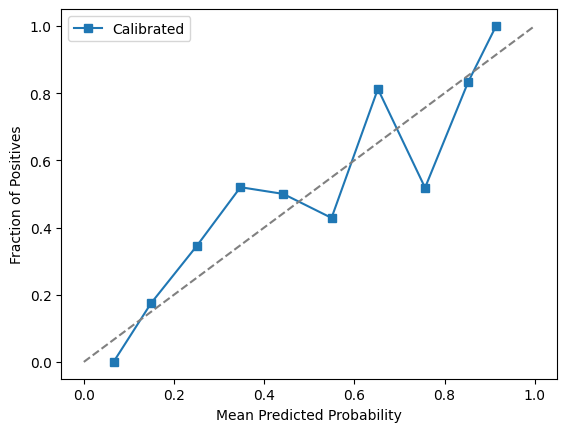

Calibrated   Brier: 0.1330441028069949
Calibrated   ROC AUC: 0.8989916023068362


In [ ]:
# Wrap & fit a sigmoid calibrator with 5-fold CV
calibrator = CalibratedClassifierCV(
    estimator=best_rf,  
    cv=5,
    method='sigmoid'
)
calibrator.fit(X_train, y_train)

# Get calibrated probabilities
y_proba_cal = calibrator.predict_proba(X_test)[:, 1]

# Compute calibration‐curve data
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)


# Calibration curves
plt.plot(prob_pred_cal, prob_true_cal, marker='s', label='Calibrated')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.show()

print("Calibrated   Brier:", brier_score_loss(y_test, y_proba_cal))
print("Calibrated   ROC AUC:", roc_auc_score(y_test, y_proba_cal))

In [ ]:
# Evaluate on test set
y_pred  = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:,1]

# Brier score (mean squared error of the probabilities)
brier = brier_score_loss(y_test, y_proba_cal)
print(f"Brier score: {brier:.4f}")

# confusion matrix & classification report at threshold 0.5
for thr in [0.5]:
    y_thr = (y_proba_cal >= thr).astype(int)
    cm_thr = confusion_matrix(y_test, y_thr)
    print(f"\nThreshold={thr} Confusion Matrix:\n{cm_thr}")
    print(classification_report(y_test, y_thr))

# Weighted cross-entropy 
classes = np.unique(y_test)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_test)
class_weight_dict = dict(zip(classes, cw))
sample_weights = np.array([class_weight_dict[y] for y in y_test])

wlog = log_loss(y_test, y_proba_cal, sample_weight=sample_weights)
print(f"Weighted log-loss: {wlog:.4f}")

Brier score: 0.1330

Threshold=0.5 Confusion Matrix:
[[166  33]
 [ 39 110]]
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       199
           1       0.77      0.74      0.75       149

    accuracy                           0.79       348
   macro avg       0.79      0.79      0.79       348
weighted avg       0.79      0.79      0.79       348

Weighted log-loss: 0.4155


/var/folders/8m/xsxvn0ns46dg_dpnlhpkxk6r0000gn/T/ipykernel_32004/1103931881.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby('bin')['true'].value_counts().unstack().fillna(0)


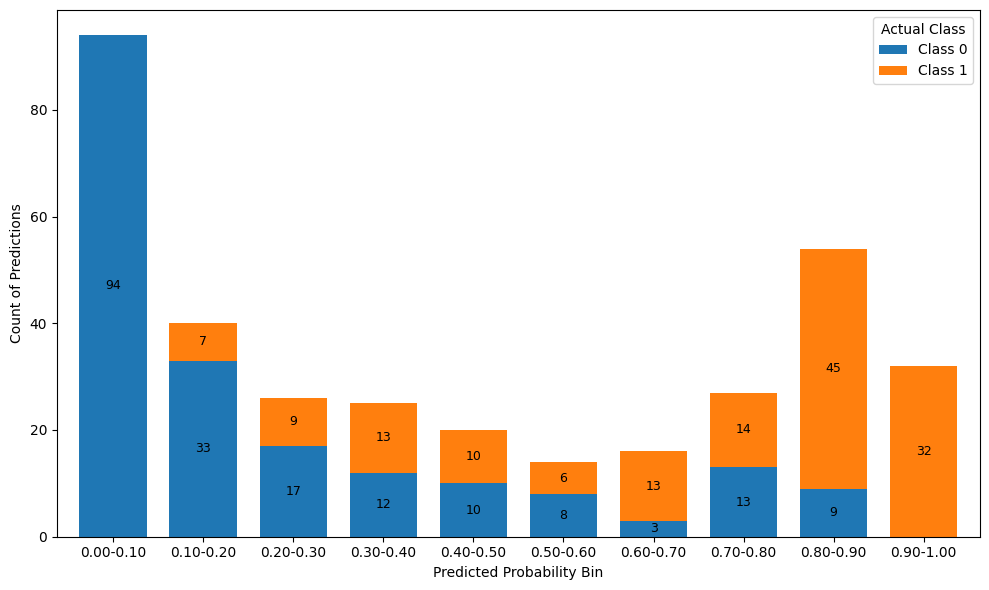

In [ ]:
# Create bins
bins = np.arange(0, 1.1, 0.1)
bin_labels = [f"{b:.2f}-{b+0.1:.2f}" for b in bins[:-1]]

# Bin the probabilities
df = pd.DataFrame({
    'prob': y_proba_cal,
    'true': y_test,
    'bin': pd.cut(y_proba_cal, bins=bins, labels=bin_labels, include_lowest=True)
})

# Count correct and wrong predictions in each bin
counts = df.groupby('bin')['true'].value_counts().unstack().fillna(0)
counts.columns = ['Class 0', 'Class 1']

fig, ax = plt.subplots(figsize=(10, 6))   
counts.plot(kind='bar', 
            stacked=True, 
            ax=ax, 
            width=0.75)                   
plt.xlabel('Predicted Probability Bin')
plt.ylabel('Count of Predictions')
plt.xticks(rotation=0)
plt.legend(title='Actual Class', loc='upper right')
plt.tight_layout()

# Add counts on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        x, y = p.get_xy() 
        ax.annotate(f'{int(height)}', 
                    (x + p.get_width()/2, y + height/2), 
                    ha='center', va='center', 
                    color='black', fontsize=9)

plt.show()
